# DecisionTreeClassifier - TF-IDF + SelectKBest

Pipeline: Text cleaning -> TF-IDF unigram + bigram -> SelectKBest(chi2) -> DecisionTreeClassifier.


## 1. Import thư viện

In [1]:
import os
import re
import json
import time
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Config

In [3]:
PROJECT_DIR = "/content/drive/MyDrive/Sentimental Analysis"

TRAIN_PATH = f"{PROJECT_DIR}/data_cleanedData/train.csv"
VAL_PATH = f"{PROJECT_DIR}/data_cleanedData/val.csv"
TEST_PATH = f"{PROJECT_DIR}/data_cleanedData/test.csv"

TEXT_COL = "text"
LABEL_COL = "status"

MODEL_DIR = f"{PROJECT_DIR}/model_results/DecisionTree"
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE = 42
CMAP = "YlGnBu"

## 4. Text cleaning

In [4]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"&\w+;", " ", text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

## 5. Load data

In [5]:
def load_dataset(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Không tìm thấy file: {path}")

    df = pd.read_csv(path)

    if TEXT_COL not in df.columns or LABEL_COL not in df.columns:
        raise ValueError(
            f"File {path} cần có 2 cột '{TEXT_COL}' và '{LABEL_COL}'. "
            f"Các cột hiện có: {list(df.columns)}"
        )

    df = df[[TEXT_COL, LABEL_COL]].dropna()
    df[TEXT_COL] = df[TEXT_COL].astype(str).apply(clean_text)
    df = df[df[TEXT_COL].str.len() > 0].reset_index(drop=True)

    return df


train_df = load_dataset(TRAIN_PATH)
val_df = load_dataset(VAL_PATH)
test_df = load_dataset(TEST_PATH)

print(f"Train size: {len(train_df):,}")
print(f"Val size:   {len(val_df):,}")
print(f"Test size:  {len(test_df):,}")

print("\nTrain label distribution:")
print(train_df[LABEL_COL].value_counts())

Train size: 34,596
Val size:   4,942
Test size:  9,886

Train label distribution:
status
normal        12702
depression    10154
suicidal       7839
anxiety        3901
Name: count, dtype: int64


## 6. Build pipeline

Dùng SelectKBest(chi2) để giảm số chiều TF-IDF trước khi đưa vào Decision Tree, giúp train nhẹ hơn và giảm overfitting.

In [6]:
pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95,
            max_features=100000,
            sublinear_tf=True,
            strip_accents="unicode"
        )
    ),
    (
        "select",
        SelectKBest(
            score_func=chi2,
            k=20000
        )
    ),
    (
        "clf",
        DecisionTreeClassifier(
            criterion="gini",
            max_depth=50,
            min_samples_split=10,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

## 7. Train + đo training time

In [7]:
X_train = train_df[TEXT_COL]
y_train = train_df[LABEL_COL]

X_val = val_df[TEXT_COL]
y_val = val_df[LABEL_COL]

X_test = test_df[TEXT_COL]
y_test = test_df[LABEL_COL]

print("Training TF-IDF + SelectKBest + DecisionTreeClassifier...")

start_train = time.perf_counter()
pipeline.fit(X_train, y_train)
train_time = time.perf_counter() - start_train

print("Training done.")
print(f"Training time: {train_time:.4f} seconds")

Training TF-IDF + SelectKBest + DecisionTreeClassifier...
Training done.
Training time: 46.5098 seconds


## 8. Confusion matrix

In [8]:
def plot_confusion_matrix_png(cm, labels, split_name):
    title = f"{split_name.upper()} Confusion Matrix"
    file_name = f"{split_name}_confusion_matrix.png"

    fig, ax = plt.subplots(figsize=(8, 6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    disp.plot(
        ax=ax,
        cmap=CMAP,
        values_format="d",
        xticks_rotation=45,
        colorbar=True
    )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    plt.tight_layout()

    save_path = os.path.join(MODEL_DIR, file_name)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved confusion matrix plot: {save_path}")

## 9. Evaluate + đo inference time

===== VAL RESULT =====
Accuracy:             0.6671
Macro F1:             0.6428
Weighted F1:          0.6670
Inference time total: 0.7530 seconds
Avg inference time:   0.00015237 seconds/sample

              precision    recall  f1-score   support

     anxiety     0.5750    0.7092    0.6350       557
  depression     0.5994    0.5589    0.5785      1451
      normal     0.8456    0.8335    0.8395      1814
    suicidal     0.5197    0.5170    0.5184      1120

    accuracy                         0.6671      4942
   macro avg     0.6349    0.6546    0.6428      4942
weighted avg     0.6690    0.6671    0.6670      4942



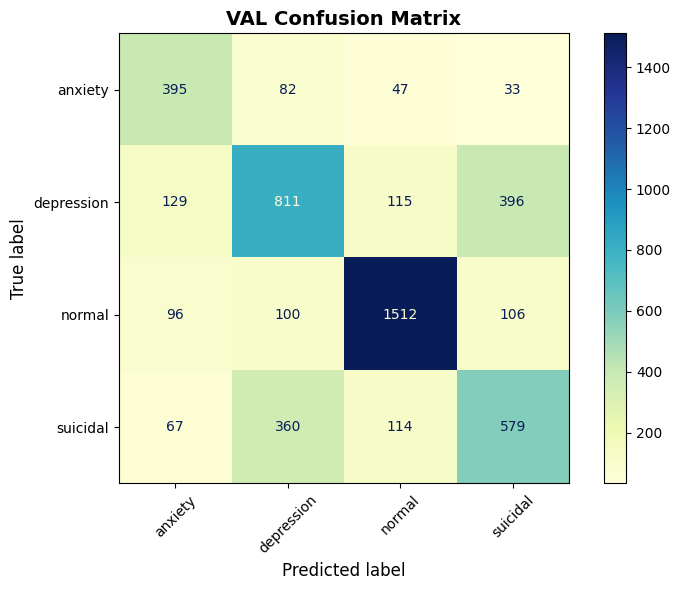

Saved confusion matrix plot: /content/drive/MyDrive/Sentimental Analysis/model_results/DecisionTree/val_confusion_matrix.png
===== TEST RESULT =====
Accuracy:             0.6636
Macro F1:             0.6378
Weighted F1:          0.6653
Inference time total: 1.4236 seconds
Avg inference time:   0.00014400 seconds/sample

              precision    recall  f1-score   support

     anxiety     0.5633    0.6825    0.6172      1115
  depression     0.5820    0.5586    0.5701      2902
      normal     0.8679    0.8308    0.8489      3629
    suicidal     0.5110    0.5192    0.5151      2240

    accuracy                         0.6636      9886
   macro avg     0.6310    0.6478    0.6378      9886
weighted avg     0.6688    0.6636    0.6653      9886



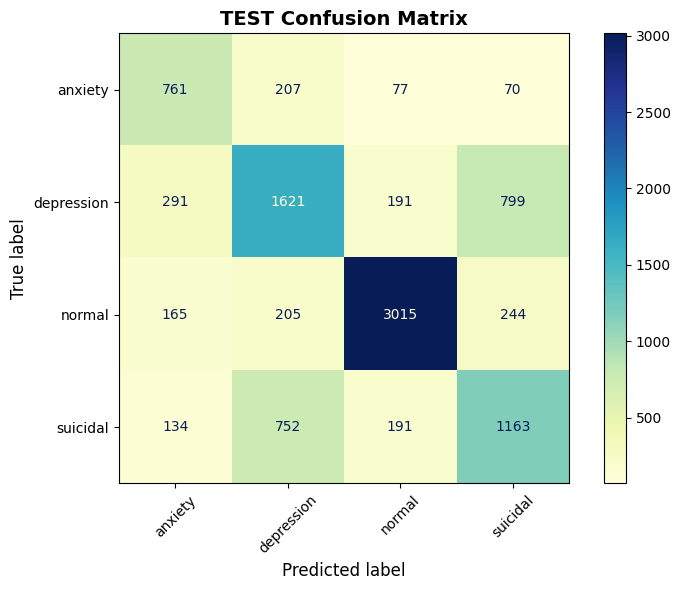

Saved confusion matrix plot: /content/drive/MyDrive/Sentimental Analysis/model_results/DecisionTree/test_confusion_matrix.png


In [9]:
def evaluate_model(split_name, X, y_true):
    start_infer = time.perf_counter()
    y_pred = pipeline.predict(X)
    infer_time_total = time.perf_counter() - start_infer
    infer_time_avg = infer_time_total / len(X)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"===== {split_name.upper()} RESULT =====")
    print(f"Accuracy:             {acc:.4f}")
    print(f"Macro F1:             {macro_f1:.4f}")
    print(f"Weighted F1:          {weighted_f1:.4f}")
    print(f"Inference time total: {infer_time_total:.4f} seconds")
    print(f"Avg inference time:   {infer_time_avg:.8f} seconds/sample")
    print()

    print(classification_report(y_true, y_pred, digits=4))

    labels = sorted(pd.Series(y_true).unique())
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    pred_df = pd.DataFrame({
        "text": X.values,
        "true_label": y_true.values,
        "pred_label": y_pred
    })
    pred_df.to_csv(os.path.join(MODEL_DIR, f"{split_name}_predictions.csv"), index=False)

    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    cm_df.to_csv(os.path.join(MODEL_DIR, f"{split_name}_confusion_matrix.csv"))

    plot_confusion_matrix_png(cm, labels, split_name)

    report_dict = classification_report(y_true, y_pred, digits=4, output_dict=True)
    with open(os.path.join(MODEL_DIR, f"{split_name}_classification_report.json"), "w", encoding="utf-8") as f:
        json.dump(report_dict, f, indent=4, ensure_ascii=False)

    return {
        "split": split_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "infer_time_total_sec": infer_time_total,
        "infer_time_avg_sec_per_sample": infer_time_avg
    }


val_metrics = evaluate_model("val", X_val, y_val)
test_metrics = evaluate_model("test", X_test, y_test)

## 10. Save model + metrics

In [10]:
model_path = os.path.join(MODEL_DIR, "decision_tree_tfidf_selectkbest.joblib")
joblib.dump(pipeline, model_path)

metrics = {
    "model": "TF-IDF + SelectKBest(chi2) + DecisionTreeClassifier",
    "feature_extraction": {
        "tfidf": {
            "analyzer": "word",
            "ngram_range": [1, 2],
            "min_df": 3,
            "max_df": 0.95,
            "max_features": 100000,
            "sublinear_tf": True
        },
        "select_k_best": {
            "score_func": "chi2",
            "k": 20000
        }
    },
    "classifier": {
        "name": "DecisionTreeClassifier",
        "criterion": "gini",
        "max_depth": 50,
        "min_samples_split": 10,
        "min_samples_leaf": 5,
        "class_weight": "balanced",
        "random_state": RANDOM_STATE
    },
    "training_time_sec": train_time,
    "val": val_metrics,
    "test": test_metrics,
    "val_infer_time_total_sec": val_metrics["infer_time_total_sec"],
    "val_infer_time_avg_sec_per_sample": val_metrics["infer_time_avg_sec_per_sample"],
    "test_infer_time_total_sec": test_metrics["infer_time_total_sec"],
    "test_infer_time_avg_sec_per_sample": test_metrics["infer_time_avg_sec_per_sample"]
}

with open(os.path.join(MODEL_DIR, "metrics_summary.json"), "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4, ensure_ascii=False)

print(f"Saved model to: {model_path}")
print(f"Saved metrics to: {os.path.join(MODEL_DIR, 'metrics_summary.json')}")
print(f"Saved reports and confusion matrices to folder: {MODEL_DIR}")

Saved model to: /content/drive/MyDrive/Sentimental Analysis/model_results/DecisionTree/decision_tree_tfidf_selectkbest.joblib
Saved metrics to: /content/drive/MyDrive/Sentimental Analysis/model_results/DecisionTree/metrics_summary.json
Saved reports and confusion matrices to folder: /content/drive/MyDrive/Sentimental Analysis/model_results/DecisionTree


## 11. Demo prediction

In [11]:
def predict_text(text):
    cleaned = clean_text(text)
    return pipeline.predict([cleaned])[0]


sample_text = "I feel anxious and my heart is racing all the time"
print("Sample prediction:")
print(f"Text: {sample_text}")
print(f"Prediction: {predict_text(sample_text)}")

Sample prediction:
Text: I feel anxious and my heart is racing all the time
Prediction: anxiety
